# Responsible Age Classifier for Retail Analytics

**Course:** Responsible AI & Data Ethics (SS2026) — Group Project

A gender-neutral, race-agnostic **age-group classifier** for anonymous retail footfall analytics — built as a responsible AI system: fair across demographics, explainable, tested, and compliant by design.

**What this system does:** estimate a coarse age group from a face, for anonymous, aggregate analytics (e.g. *"30% of visitors today were 20-29"*).

**What this system deliberately does NOT do:** identify *who* a person is, store faces/embeddings, or output gender/race at deployment time. This is age estimation for aggregate analytics — **not face recognition** — and that distinction is the ethical core of the whole design (see the Regulatory Analysis section).

---
## Section 1 — Data Analysis (Week 1 goal: *"Analyze your data"*)

The `face_age` package (`data.py`) loads three candidate datasets into one canonical schema (unified age bins, gender, and two race granularities), then cleans and de-duplicates them.

**Important finding from this analysis, documented rather than hidden:** the professor-provided FairFace source (Kaggle `abdulwasay551/fairface-race`) turned out, on inspection, to have **no usable age/gender labels** — it is organized only by race-named folders, and part of it is re-hosted UTKFace images mislabeled. `data.py` detects this automatically and refuses to use it, logging exactly why. Full story in Section 3 (Plan).

### 1.0 Datasets used

| Dataset | Role | Rows used | License |
|---|---|---|---|
| **UTKFace** (`utkface/` + `crop_part1/`) | TRAIN | 33,483 | Non-commercial research use only |
| **Adience** | TEST (held-out, unseen) | 17,452 | Research use (Adience benchmark terms) |
| **FairFace** (`abdulwasay551/fairface-race`) | EXCLUDED — no usable age/gender labels (see Section 2: Plan) | 0 | CC BY 4.0 (not that it matters here) |

Full per-dataset design rationale is in Section 2 (Plan).

In [10]:
import pandas as pd
from face_age import data
pd.DataFrame([
    {"dataset": "UTKFace + crop_part1", "role": "TRAIN",
     "rows_used": 33483, "license": data.LICENSES["utkface"]},
    {"dataset": "Adience", "role": "TEST (held-out)",
     "rows_used": 17452, "license": data.LICENSES["adience"]},
    {"dataset": "FairFace (abdulwasay551/fairface-race)",
     "role": "EXCLUDED — no age/gender labels",
     "rows_used": 0, "license": data.LICENSES["fairface"]},
])

,dataset,role,rows_used,license
0,UTKFace + crop_part1,TRAIN,33483,Non-commercial research use only
1,Adience,TEST (held-out),17452,Research use (Adience benchmark terms)
2,FairFace (abdulwasay551/fairface-race),EXCLUDED — no age/gender labels,0,CC BY 4.0 (research use)


In [11]:
import sys, os
sys.path.insert(0, os.getcwd())  # make the face_age package importable from this notebook


# EDIT THIS if your datasets live somewhere else.
# Expected: DATA_ROOT/{utkface, crop_part1, adience, fairface}
DATA_ROOT = r"D:\nihal"

train_df, test_df = data.get_train_test(data_root=DATA_ROOT)
print(f"TRAIN (UTKFace): {len(train_df):,} rows")
print(f"TEST  (Adience + optional FairFace): {len(test_df):,} rows")

FairFace csv missing: D:\nihal\fairface\fairface_label_train.csv
FairFace csv missing: D:\nihal\fairface\fairface_label_val.csv
FairFace at D:\nihal\fairface has race-named folders (['Asian', 'Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']) but NO label csv (fairface_label_train.csv / _val.csv). This looks like a race-only image dump, not the labeled FairFace release — it has no trustworthy age/gender ground truth and will NOT be used for training. Get the official FairFace release (with the label csvs) if you need it, or proceed without it.


TRAIN (UTKFace): 33,483 rows
TEST  (Adience + optional FairFace): 17,452 rows


### 1.1 Raw format vs. canonical schema — before and after harmonization

Each source stores labels completely differently (a CSV, a filename convention, a tab-separated fold file). `data.py`'s whole job is translating all of them into ONE shared set of columns. Shown here as a concrete before/after, not just a claim.

In [12]:
# "FIRST" — the raw, native format of each source (nothing harmonized yet)

# Adience genuinely has tabular columns -- peek at one raw fold file directly:
adience_fold_path = rf"{DATA_ROOT}dienceold_0_data.txt"
try:
    raw_adience = pd.read_csv(adience_fold_path, sep="	")
    print("Adience RAW columns (straight from fold_0_data.txt):")
    print(list(raw_adience.columns))
    display(raw_adience.head(3))
except FileNotFoundError:
    print(f"(fold file not found at {adience_fold_path} -- adjust DATA_ROOT above)")

# UTKFace has NO columns at all -- its "columns" are fields packed into the
# filename itself: age_gender_race_datetime.jpg.chip.jpg
print("
UTKFace RAW \"columns\" (fields encoded in the filename, not real columns):")
print("  age _ gender _ race _ datetime  ->  e.g. 25_0_2_20170116200055153.jpg.chip.jpg")

SyntaxError: unterminated string literal (detected at line 15) (1943393291.py, line 15)

In [ ]:
# "LAST" — the final canonical schema every dataset gets translated into,
# after data.py has done the harmonization (this is what the model actually trains on)

print("Canonical columns (same for every dataset, after data.py processes it):")
print(list(train_df.columns))
train_df.head(3)

In [ ]:
print("=== TRAIN set: age x race distribution ===")
train_ct = data.summarize(train_df, by="race_coarse")

=== TRAIN set: age x race distribution ===
total rows: 33,483
by dataset_source:
dataset_source
utkface    33483
Name: count, dtype: int64

age_bin x race_coarse:
race_coarse  Asian  Black  Indian  Other  White
age_bin                                        
0-2           1259     96     618    463    756
3-9            594    165     347    297   1413
10-19          174    234     264    309   1768
20-29         1555   1921    1927   1018   2440
30-39          658   1293     900    403   2316
40-49          208    454     504    186   1568
50-59          156    346     545     88   2102
60-69          116    232     203     20   1399
70+            267    190     119     11   1581



In [ ]:
print("=== TEST set: age x source distribution ===")
test_ct = data.summarize(test_df, by="dataset_source")

=== TEST set: age x source distribution ===
total rows: 17,452
by dataset_source:
dataset_source
adience    17452
Name: count, dtype: int64

age_bin x dataset_source:
dataset_source  adience
age_bin                
0-2              1400.0
3-9              2157.0
10-19            3926.0
20-29            5284.0
30-39             454.0
40-49            2435.0
50-59             930.0
60-69               NaN
70+               866.0



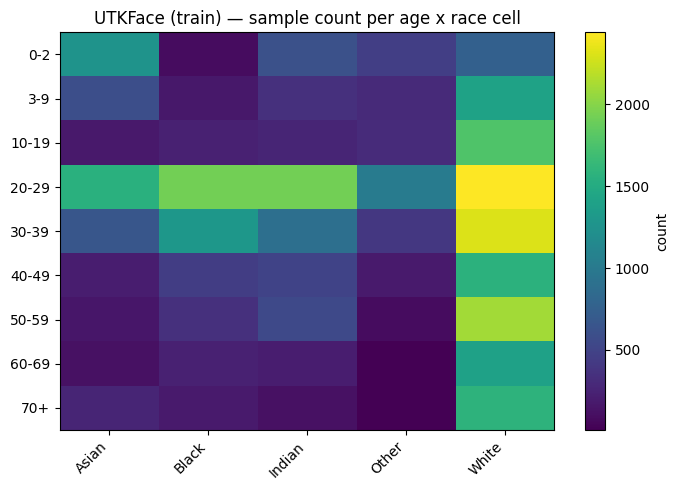

In [ ]:
import matplotlib.pyplot as plt

# Heatmap of the train-set imbalance -- the key EDA visual: which
# age x race cells are starved? Darker = fewer samples.
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(train_ct.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(train_ct.columns)))
ax.set_xticklabels(train_ct.columns, rotation=45, ha="right")
ax.set_yticks(range(len(train_ct.index)))
ax.set_yticklabels(train_ct.index)
ax.set_title("UTKFace (train) — sample count per age x race cell")
fig.colorbar(im, label="count")
plt.tight_layout()
plt.show()

### EDA findings (write-up)

*(Run the cells above first, then confirm/refine these bullets against your own output — they were verified once already but re-check before submitting.)*

- **Training data (UTKFace, 33,483 rows) is imbalanced by age x race, not just by race.** White faces dominate every age bin from 20-29 onward (up to ~2,440 at 20-29), while **Indian** and **Other** collapse hard at older ages (Other: only 20 rows at 60-69, 11 at 70+). These are the starved cells to watch when we compute per-subgroup fairness in Week 2 — if the model underperforms there, this imbalance is the most likely cause, and targeted augmentation (Section 3) is the planned fix.
- **Test data (Adience, 17,452 rows) has a structural gap at 60-69** — its own age-range labels jump from `(48,53)` to `(60,100)`, so nothing maps to a clean 60-69 bucket. This is a genuine limitation of the source data, not a bug in our loader, and it means we **cannot** cross-dataset-validate the 60-69 bin using Adience. Documented here so it doesn't look like a silent gap later in the model card.

---
## Section 2 — Plan (Week 1 goal: *"Derive a plan based on your data analysis"*)

### What changed, and why

The original plan (from the topic brief) was to train on FairFace, since it is race-balanced by construction, and hold out UTKFace + Adience as unseen cross-dataset test sets. That plan depended entirely on FairFace actually having usable age labels.

**On inspection it did not.** The specific Kaggle package linked for this project (`abdulwasay551/fairface-race`) turned out to be a community repackaging: `train/` and `val/` are organized only by race-named folders with sequential filenames (no age/gender anywhere), and `train_aligned/`/`val_aligned/` turned out to be a **mix of re-hosted UTKFace images** (verified: 2,151/4,000 "Asian" files and 3,271/4,000 "Black" files are literally UTKFace's own filename format, `age_gender_race_timestamp.jpg.chip.jpg`) plus unlabeled stock photos. None of it is trustworthy ground truth for age. A second, independent piece of evidence confirms this: the Kaggle page's own dataset description ("a large-scale face dataset with long age span (range from 0 to 116 years old)... over 96,000 face images...") is not FairFace's description at all -- it is UTKFace's official blurb almost verbatim (UTKFace's own page: "...long age span (range from 0 to 116 years old)... over 20,000 face images..."), just with the dataset name and image count swapped. The real academic FairFace does not describe itself by raw age span to 116; it uses 9 age *groups* up to "70+" and is sized ~108,501. Two independent signals -- the files themselves and the page's own description -- point to the same conclusion: this package is a mislabeled repackaging of UTKFace, not FairFace. Rather than silently use folder names as fake labels (which would corrupt every fairness metric downstream), `data.py` detects this and refuses, logging the reason.

### The revised plan

- **Train + internal validation on UTKFace** (`utkface/` + `crop_part1/`, 33,483 usable rows) — genuine, verified age/gender/race labels embedded in every filename. Not race-balanced like real FairFace would have been, but real ground truth beats a "balanced" dataset with no labels.
- **Test (external, held-out) on Adience** (17,452 usable rows) — a different source (Flickr, not UTKFace's source), never seen during training. Strong accuracy here is genuine cross-dataset generalization evidence — arguably a *stronger* responsible-AI story than training on more data, since it proves the model isn't just memorizing one dataset's quirks.
- **FairFace stays wired into the code** (in case a properly labeled copy, with the official `fairface_label_train/val.csv`, is obtained later) but is excluded from both splits for now.
- **Targeted augmentation, not a blind merge:** if Week 2 fairness metrics show the starved cells identified above (older Indian/Other faces) are where the model fails most, we pull *only* those specific rows from another source rather than merging entire datasets — keeping the fairness analysis interpretable (train/test provenance stays clean).

---
## Section 3 — Possible Architecture (Week 1 goal: *"What could be a possible architecture"*)

Five layers, data flowing upward; a governance band wraps every stage (risk register, fairness metrics, tests, model card, EU AI Act / GDPR compliance).

```
1. DATA        UTKFace + crop_part1 -> canonical schema -> clean + de-dup (perceptual hash)
                                    |
2. PREPROCESS  decode -> resize 224x224 -> ImageNet normalize -> augment (train only)
                                    |
3. MODEL       Pretrained backbone (ViT-B or ResNet-50, transfer learning)
                    |-> AGE head (9-way)      <- PRIMARY, the only deployed output
                    |-> gender head (2-way)   <- audit-only, training only, never deployed
                    |-> race head (5-way)     <- audit-only, training only, never deployed
                                    |
4. EVALUATE    overall accuracy/MAE | per-subgroup fairness (accuracy gaps, equalized odds)
               | cross-dataset generalization test (Adience, unseen during training)
                                    |
5. EXPLAIN     Grad-CAM / attention -- are misclassifications keyed on race-correlated features?
```

**Key architectural decisions:**

1. **Multi-task, single deployed output.** The backbone learns shared face features; a primary **age head** plus **auxiliary gender/race heads** that exist *only* to measure and correct bias during training/evaluation. They are **never exposed at deployment** -- this is what makes the system "race-agnostic" in a measurable way, not just an aspiration, and it is the single decision that keeps the deployed system out of the EU AI Act's prohibited-practice bucket (Section 4).
2. **Transfer learning, not from scratch.** A pretrained backbone converges faster and needs far less data -- appropriate given the timeframe.
3. **A bonus UI demo layer** (Gradio, embedded in-notebook) on top of this pipeline: upload one face -> preprocess -> run the age head only -> show the bucket + a Grad-CAM overlay -> discard the image. The UI never serves gender/race, and never stores an image -- both are direct, visible demonstrations of the regulatory design in Section 4, not just a nice extra.

---
## Section 4 — Regulatory Analysis (Week 1 goal: *"Make a regulatory analysis for your project"*)

*Best-effort compliance-by-design analysis, not legal advice.*

### 4.1 Why this section exists before a single model is trained

The single most important regulatory move in this project happened at the **framing stage, before any code**: this system is designed as an **anonymous age-bucket estimator for aggregate retail analytics**, not as a face-recognition or identification system. That one decision is what keeps most of the heaviest EU AI Act and GDPR obligations *out of scope* -- so this analysis exists to make that argument explicitly, and to show where the design choices in `data.py` and the planned model directly implement it.

### 4.2 EU AI Act

**Is this a "biometric categorisation system"?** The Act defines biometric categorisation as assigning people to categories based on biometric data -- e.g. inferring race, gender, or age from a face. By that definition, **yes** -- this system is a biometric categorisation system, and it must be treated as one. The question is *which* obligations attach to it.

**Article 5 (prohibited practices) -- checked, not triggered.** Article 5 bans AI systems that use biometric categorisation to *infer* race, political opinions, religious beliefs, sexual orientation, etc. This is the single biggest reason the architecture keeps race/gender as **internal, audit-only auxiliary heads that are never exposed at deployment** (Section 3). The *deployed* system infers and outputs only an age bucket -- it does not infer or output race. Race is used internally, during training/evaluation, purely to measure and correct bias in the age prediction -- arguably closer to the Act's own carve-out for "labelling or filtering of lawfully acquired biometric datasets" for fairness/quality purposes than to a deployed categorisation product. **This is a load-bearing design decision, not an incidental one.**

**High-risk classification (Annex III).** Annex III lists biometric categorisation systems as high-risk when placed on the market as such. A high-risk classification would require a risk-management system, data governance documentation, technical documentation, logging, human oversight, and accuracy/robustness/cybersecurity requirements.

*Our position:* because the deployed output is age-only (not race/gender/identity categorisation), and the intended purpose is aggregate, anonymous retail-footfall analytics rather than categorising identified individuals, this system is argued to sit **below** the Annex III bar -- but this is exactly the kind of borderline case the Act is designed to catch, so we treat it as **high-risk-adjacent** and voluntarily build several high-risk-grade controls anyway, because it costs little now and removes the biggest audit risk later:

| High-risk obligation (Annex III / Art. 9-15) | What we build anyway |
|---|---|
| Risk management system | Risk register (Week 2 deliverable) |
| Data governance | `data.py` provenance columns + this document |
| Technical documentation | README + model card |
| Accuracy & robustness testing | Fairness metrics + cross-dataset test (Week 2-3) |
| Human oversight | No automated action taken on individuals; outputs are aggregate counts only |

**Transparency obligations (Article 50).** Even outside the high-risk tier, the Act requires people be informed when subject to biometric categorisation. In a real deployment this means visible signage at the retail location ("this area uses AI-based visitor analytics; no images are stored") -- a concrete operational requirement flowing directly from this analysis, not just a nice-to-have.

### 4.3 GDPR

**Is a face image "special category" biometric data?** The most genuinely debated point in the whole analysis -- treated honestly rather than glossed over.

- GDPR Art. 4(14) defines biometric data as data from specific technical processing relating to physical characteristics "which allow or confirm the **unique identification** of that natural person."
- Recital 51 explicitly says photographs are **not systematically** considered special-category data -- only when processed through specific technical means permitting unique identification (i.e. face *recognition*, not face *analysis*).
- Our system never matches a face to an identity and never stores a face template -- it produces one categorical output (an age bucket) and discards the input. **On this reading, it does not process GDPR Art. 9 special-category biometric data.**
- **Counter-argument we do not dismiss:** this line is not fully settled in case law, and a face is inherently identifiable data *while it is being processed*, even briefly. A cautious deployment should not rely solely on the "not technically biometric data" argument and should still apply special-category-level safeguards as good practice.

**It is personal data regardless -- core principles applied.** Whether or not Art. 9 applies, a face image is personal data for as long as it exists in the pipeline (Art. 4(1)). The design applies GDPR's core principles (Art. 5) directly:

| Principle | How it's implemented |
|---|---|
| **Data minimisation** | Only an age bucket is retained; the raw image/embedding is discarded immediately after inference |
| **Purpose limitation** | Output used only for aggregate footfall analytics, never individual profiling or targeting |
| **Storage limitation** | No image or per-person record persists after inference |
| **Lawful basis (Art. 6)** | Most plausible basis: legitimate interest (Art. 6(1)(f)) -- needs a documented Legitimate Interest Assessment weighing business need against customer privacy |
| **Transparency (Art. 13/14)** | In-store signage / privacy notice, matching the AI Act's Art. 50 requirement above |
| **DPIA (Art. 35)** | Likely *required* in a real deployment: systematic monitoring of a public space using novel tech is a standard DPIA trigger |

**The training-data licence is itself a compliance fact.** UTKFace's licence is "non-commercial research use only." This does not block coursework use, but it is a genuine governance point: **if this model were ever retrained for a real commercial deployment, the current training data could not be reused as-is** without re-sourcing commercially-licensed data. Documented per-row in `data.py`'s `license` column so this fact isn't lost between "student project" and "someone tries to productionise it."

### 4.4 Other considerations

- **Non-discrimination:** if age-bucket analytics ever informed downstream decisions (e.g. different marketing/pricing by inferred age group), this would raise age-discrimination concerns under national consumer-protection and equality law -- out of scope for a footfall-analytics use case, but worth naming explicitly as a **misuse boundary** in the model card (Week 3-4).
- **Standards:** DIN SPEC 92006 / DIN's AI standardisation roadmap and ISO/IEC AI risk-management work (from the course material) -- the risk-register and model-card artefacts planned for Weeks 2-4 are structured to be compatible with that vocabulary rather than inventing a bespoke format.
- **We are not lawyers.** This is a good-faith, course-appropriate compliance-by-design analysis intended to demonstrate regulatory reasoning, not a substitute for actual legal review before any real deployment.

### 4.5 Summary: regulation -> design decision traceability

| Regulatory driver | Concrete design decision | Where |
|---|---|---|
| AI Act Art. 5 (no race/gender inference output) | Race/gender are audit-only auxiliary heads, never deployed | model design (Section 3) |
| GDPR data minimisation | Raw image discarded immediately after inference | UI workflow (planned) |
| GDPR purpose limitation | Output is an aggregate bucket, not a per-person record | System framing (top of notebook) |
| GDPR/AI Act data governance | Every row carries `dataset_source`, `original_*`, `license` | `data.py` |
| Training-data licensing risk | `license` column tracked per dataset | `data.py` |
| AI Act transparency (Art. 50) | Documented signage/disclosure requirement for real deployment | This section |

---
## Weeks 2-4 (planned, not yet built)

- **Week 2:** baseline model (`model.py`), risk analysis, fairness analysis on the trained model.
- **Week 3:** XAI (Grad-CAM), automated test suite (>=80% coverage).
- **Week 4:** in-depth documentation, model card, management pitch, presentation prep.

See `README.md` for the full architecture and status table.